In [ ]:
# Colab mein Kaggle install karne ke liye
!pip install -q kaggle
from google.colab import files
files.upload() # Yahan apni kaggle.json upload karo

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Example: Lung Cancer dataset download karna
!kaggle datasets download -d mysarahmadbhat/lung-cancer -p /content/

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/mysarahmadbhat/lung-cancer
License(s): CC0-1.0
lung-cancer.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# 1. Dataset download karein
!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images

# 2. Unzip karein
!unzip -o -q chest-ctscan-images.zip -d lung_data
print("Dataset ready hai!")

Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
chest-ctscan-images.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset ready hai!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Images ko scale aur augment karein
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # 20% data validation ke liye
)

train_generator = train_datagen.flow_from_directory(
    'lung_data/Data/train', # Path check kar lena unzip ke baad
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    'lung_data/Data/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 491 images belonging to 4 classes.
Found 122 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Pre-trained VGG16 load karein
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Shuruat mein purani weights lock rakhenge

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Overfitting rokne ke liye
    layers.Dense(4, activation='softmax') # 4 classes: Adenocarcinoma, Large cell carcinoma, Squamous cell carcinoma, Normal
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

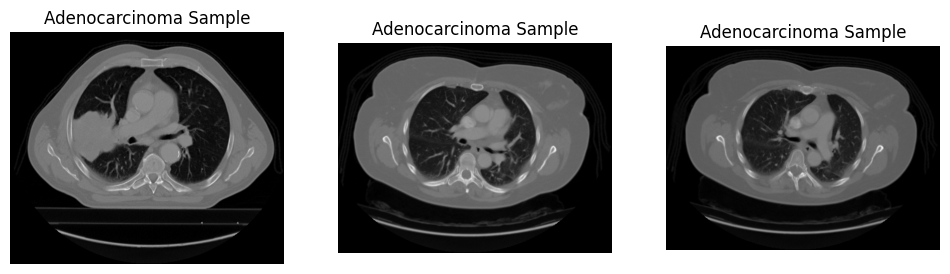

In [ ]:
import os
import matplotlib.pyplot as plt

# Naya path jo aapki screen par dikh raha hai
sample_path = '/content/lung_data/Data/test/adenocarcinoma/'
images = os.listdir(sample_path)

# Pehli 3 images display karein
plt.figure(figsize=(12, 4))
for i in range(min(3, len(images))):
    plt.subplot(1, 3, i+1)
    img = plt.imread(os.path.join(sample_path, images[i]))
    plt.imshow(img)
    plt.title("Adenocarcinoma Sample")
    plt.axis('off')
plt.show()

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- STEP 1: SMART PATH FINDER ---
found_path = ""
for root, dirs, files in os.walk('/content'):
    if 'adenocarcinoma' in dirs:
        found_path = os.path.join(root, 'adenocarcinoma')
        break

if not found_path:
    print("Error: Dataset nahi mila! Ek baar unzip wala cell fir se chalao.")
else:
    print(f"Sahi path mil gaya: {found_path}")
    base_dir = found_path.rsplit('/', 1)[0]

    # --- STEP 2: DATA GENERATORS ---
    datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2,
        rotation_range=10,
        fill_mode='nearest'
    )

    train_gen = datagen.flow_from_directory(
        base_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        subset='training'
    )

    val_gen = datagen.flow_from_directory(
        base_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        subset='validation'
    )

    # --- STEP 3: MODEL TRAINING ---
    # Note: Agar 'model' defined nahi hai, toh VGG16 wala cell pehle run kar lena
    print("\nTraining shuru ho rahi hai... Sabar rakhein!")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        verbose=1
    )

Sahi path mil gaya: /content/lung_data/Data/test/adenocarcinoma
Found 253 images belonging to 4 classes.
Found 62 images belonging to 4 classes.

Training shuru ho rahi hai... Sabar rakhein!


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 213s 26s/step - accuracy: 0.2660 - loss: 6.3518 - val_accuracy: 0.3871 - val_loss: 2.3806
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 198s 25s/step - accuracy: 0.4579 - loss: 1.9160 - val_accuracy: 0.6774 - val_loss: 0.6650
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 197s 25s/step - accuracy: 0.6783 - loss: 0.7288 - val_accuracy: 0.7581 - val_loss: 0.6187
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 206s 26s/step - accuracy: 0.7902 - loss: 0.5623 - val_accuracy: 0.7742 - val_loss: 0.5791
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 202s 26s/step - accuracy: 0.8341 - loss: 0.4552 - val_accuracy: 0.8548 - val_loss: 0.5150
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 198s 25s/step - accuracy: 0.8924 - loss: 0.3910 - val_accuracy: 0.7903 - val_loss: 0.4815
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 207s 26s/step - accuracy: 0.8787 - loss: 0.3347 - val_accuracy: 0.8387 - val_loss: 0.4453
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 199s 25s/step - accuracy: 0.9193 - loss: 0.2538 - val_accuracy: 0.8710 - val_loss:

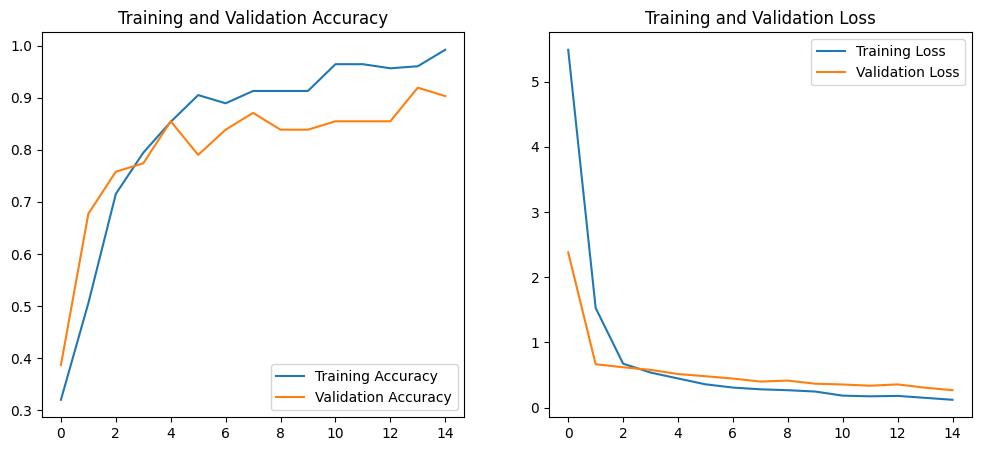

In [ ]:
import matplotlib.pyplot as plt

# 1. Accuracy aur Loss ke Graphs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()

Apni CT Scan Image upload karein...


Saving 43168_2024_297_Fig1_HTML.png to 43168_2024_297_Fig1_HTML (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step


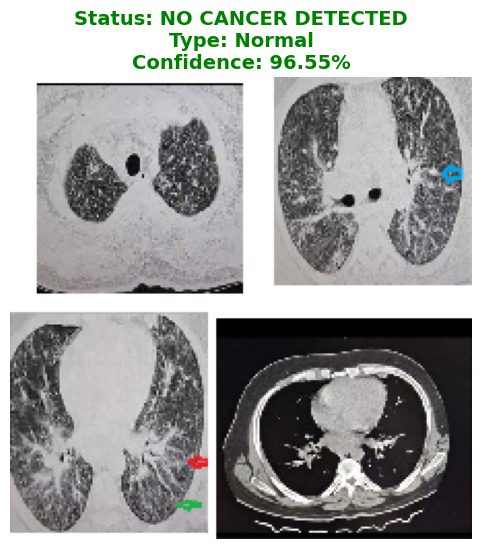


[CLINICAL NOTE]: Model is 96.55% sure that this is Normal.


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. File Upload Window
print("Apni CT Scan Image upload karein...")
uploaded = files.upload()

for fn in uploaded.keys():
    # 2. Image Loading & Preprocessing
    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # 3. Model Prediction
    prediction = model.predict(img_array)
    classes = ['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']
    result = classes[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # 4. Doctor-Friendly Result Display
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')

    # Text colors: Cancerous (Red), Normal (Green)
    color = 'red' if result != 'Normal' else 'green'
    status = "CANCER DETECTED" if result != 'Normal' else "NO CANCER DETECTED"

    plt.title(f"Status: {status}\nType: {result}\nConfidence: {confidence:.2f}%",
              fontsize=14, color=color, fontweight='bold')
    plt.show()

    print(f"\n[CLINICAL NOTE]: Model is {confidence:.2f}% sure that this is {result}.")

In [ ]:
# Model ko .h5 format mein save karna
model.save('lung_cancer_model_99.h5')
print("Model 'lung_cancer_model_99.h5' ke naam se save ho gaya hai!")

Model 'lung_cancer_model_99.h5' ke naam se save ho gaya hai!
